In [4]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1


/Users/shivam/env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from scipy.interpolate import interp1d
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt('/Users/shivam/Library/CloudStorage/Dropbox/research/GODMAX/data/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb


    





In [6]:
# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.0
sim_params_dict['delta_rhogas'] = 7.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 1.4
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.0

sim_params_dict['log10_Mc0'] = 14.0
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 1.1
sim_params_dict['nu_z'] = -0.2
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

hod_params_dict = {}
hod_params_dict['logMmin'] = 12.88
hod_params_dict['sigma_logM'] = 0.2
hod_params_dict['logM0'] = 12.88
hod_params_dict['logM1'] = 14.0
hod_params_dict['alpha'] = 1.3
sim_params_dict['hod_params'] = hod_params_dict
sim_params_dict['hod_type'] = 'Zheng05'


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 12, 48
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 1.6, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
# df = fits.open('data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.6
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)

ks = np.geomspace(5e-2,50,15) # wavenumbers
analysis_dict['k_array_survey'] = jnp.array(ks)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['sigma_epsilon_SN_bins'] = [0.2724, 0.2724, 0.2724, 0.2724]
# analysis_dict['neff_arcmin2_SN_bins'] = [1.7971, 1.5521, 1.5967, 1.0979]

analysis_dict['sigma_epsilon_SN_bins'] = [0.243, 0.262, 0.259, 0.301]
analysis_dict['neff_arcmin2_SN_bins'] = [1.476, 1.479, 1.484, 1.461]

analysis_dict['nbar_lens_bins'] = [0.5, 0.5, 0.5]

other_params_dict = {}
other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])






In [7]:
import pickle as pk

df = pk.load(open('/Users/shivam/Library/CloudStorage/Dropbox/research/GODMAX/notebooks/DV_fid_Cl_Pk_cov.pk', 'rb'))
probes_all = df['probes']
ell_edges_left = df['edges_left']
ell_edges_right = df['edges_right']
ell_array = df['ell_array']
k_array = df['k_array']
cov_total = df['cov_mat']
Cl_total = df['Cl_Pk']
bin_comb_all_wprobe = df['bin_comb_all_wprobe']




In [8]:
probes_all

['ky', 'kk', 'gy', 'gg', 'gk', 'ge']

In [9]:
import copy
from tqdm import tqdm
from get_power_spectra import get_power_BCMP
get_power_BCMP_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((cov_total.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
    if probe1 == 'kk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gg':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gy':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

edge_left_pge = ell_edges_left[-1]
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])




In [10]:
from setup_power_spectra import setup_power_BCMP
set_power_BCMP_test = setup_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, verbose_time=False)



In [ ]:
# np.amin(set_power_BCMP_test.ukg_auto), np.amax(set_power_BCMP_test.ukg_auto)
# np.amin(set_power_BCMP_test.uk_clm), np.amax(set_power_BCMP_test.uk_clm)
# np.amin(set_power_BCMP_test.Ncen), np.amax(set_power_BCMP_test.Ncen)
# np.amin(set_power_BCMP_test.Nsat), np.amax(set_power_BCMP_test.Nsat)
# np.amin(set_power_BCMP_test.nbarz), np.amax(set_power_BCMP_test.nbarz)



3969.5141314703083

In [12]:
# np.all(np.isfinite(get_power_BCMP_test.Cl_gal_gal_tot_mat))
np.amin(get_power_BCMP_test.Cl_gal_gal_tot_mat), np.amax(get_power_BCMP_test.Cl_gal_gal_tot_mat)


(Array(2.04900236e-12, dtype=float64), Array(6.32705491e-05, dtype=float64))

In [40]:
# probes_forecast = ['ky','kk', 'gy', 'gk' ,'ge']
# probes_forecast = ['kk', 'gk' ,'ge']
# probes_forecast = ['gg' ,'kk', 'gk','ge']
# probes_forecast = ['gg', 'gk', 'kk' ,'ge']
probes_forecast = ['gg', 'gk', 'kk' ]
# probes_forecast = ['kk', 'gk' ]
# probes_forecast = ['ky','kk', 'gy', 'gk' ]
ell_sel_min = []
ell_sel_max = []
for jp in range(len(probes_forecast)):
    indp = probes_all.index(probes_forecast[jp])
    # print(indp)
    ell_sel_min.append(ell_edges_left[indp])
    ell_sel_max.append(ell_edges_right[indp])
    print(probes_forecast[jp], ell_sel_min[jp], ell_sel_max[jp])

ell_sel_min = np.array(ell_sel_min)
ell_sel_max = np.array(ell_sel_max)
argsort_min = np.argsort(ell_sel_min)
probes_forecast = [probes_forecast[jp] for jp in argsort_min]
ell_sel_min = ell_sel_min[argsort_min]
ell_sel_max = ell_sel_max[argsort_min]
ell_sel_all = []
for jp in range(len(probes_forecast)):
    ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
ell_sel_all = np.concatenate(ell_sel_all)


gg 510 690
gk 690 1050
kk 120 420


In [41]:
# in a 2d matrix select multiple slice ranging from different min and max values
cov_forecast = cov_total[ell_sel_all,:][:, ell_sel_all]


In [42]:
cosmo_params_vary_names = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
sims_params_vary_names = ['theta_ej_0', 'mu_beta','nu_theta_ej_z']
# sims_params_vary_names2 = ['nu_theta_ej_M', 'nu_theta_ej_z', 'nu_z', 'log10_Mc0']
# sims_params_vary_names3 = ['mu_beta', 'delta_rhogas', 'gamma_rhogas']
IA_params_vary_names = ['A_IA', 'eta_IA']
mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']




In [43]:
import jax 
from tqdm import tqdm
import copy

def get_mean_cosmo(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(cosmo_params_vary_names)):
        sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]


cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']

cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
for jp in range(len(cosmo_params_vary_names_all)):
    cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

dmu_cosmo_all = np.zeros((len(ell_sel_all), len(cosmo_params_vary_names_all)))
for jp in tqdm(range(len(cosmo_params_vary_names_all))):
    cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
    dmu_cosmo = jac_mean(params_fid)
    dmu_cosmo_all[:, jp] = dmu_cosmo[:,0]




  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [04:29<00:00, 53.86s/it]


In [44]:
import jax 
from tqdm import tqdm

@jax.jit
def get_mean_sims(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(sim_param_vary_names)):
        sim_params_dict_vary[sim_param_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]



sims_params_vary_names_all = ['theta_ej_0', 'mu_beta' ,'alpha_nt']


sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
for jp in range(len(sims_params_vary_names_all)):
    sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]

dmu_sims_all = np.zeros((len(ell_sel_all), len(sims_params_vary_names_all)))
for jp in tqdm(range(len(sims_params_vary_names_all))):
    sim_param_vary_names = [sims_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
    dmu_sim = jac_mean(params_fid)
    dmu_sims_all[:,jp] = dmu_sim[:,0]

# F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))
# # print(np.linalg.cond(F_sims))
# cov_sims_params = np.linalg.inv(F_sims)
# print(np.sqrt(np.diag(cov_sims_params)))




100%|██████████| 3/3 [01:34<00:00, 31.63s/it]


In [45]:
import jax 
from tqdm import tqdm

@jax.jit
def get_mean_IA(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(IA_param_vary_names)):
        other_params_dict_vary[IA_param_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]

IA_params_vary_names_all = ['A_IA', 'eta_IA']

IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
for jp in range(len(IA_params_vary_names_all)):
    IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]

dmu_IA_all = np.zeros((len(ell_sel_all), len(IA_params_vary_names_all)))
for jp in tqdm(range(len(IA_params_vary_names_all))):
    IA_param_vary_names = [IA_params_vary_names_all[jp]]
    params_fid = jnp.array([other_params_dict[IA_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_IA))
    dmu_IA = jac_mean(params_fid)
    dmu_IA_all[:, jp] = dmu_IA[:, 0]




100%|██████████| 2/2 [00:50<00:00, 25.16s/it]


In [46]:
# dmu_cosmo_all
# params_fid
# dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all, dmu_IA_all], axis=1)
dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all], axis=1)
# dmu_all = np.concatenate([dmu_cosmo_all.T, dmu_sims_all.T, dmu_IA_all.T, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
# dmu_all.shape

P = jnp.linalg.inv(cov_forecast)

F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))

print(F_all.shape)




(8, 8)


In [37]:
# dmu_IA_all
# F_all

Array([[ 1.01375048e+06, -6.91869135e+05,  2.30844239e+03,
         4.75920099e+05,  3.47789916e+05, -3.73699852e+03,
        -6.21226000e+03, -6.07256880e+04],
       [-6.87567795e+05,  9.62624335e+05, -2.48348851e+03,
        -4.73257236e+05, -9.18675526e+04, -1.63685374e+03,
        -1.41690496e+03,  3.28930526e+03],
       [ 2.31086227e+03, -2.49484015e+03,  7.41828873e+00,
         1.49940330e+03,  5.53863123e+02, -4.11719279e+00,
        -6.91871808e+00, -6.24051562e+01],
       [ 4.75972308e+05, -4.75863019e+05,  1.49839619e+03,
         3.41004117e+05,  1.34328859e+05, -1.38534418e+03,
        -2.33772130e+03, -1.95215444e+04],
       [ 3.46384882e+05, -9.08547814e+04,  5.50731496e+02,
         1.33563970e+05,  2.48354376e+05, -1.20744334e+04,
        -1.62179847e+04, -6.12594663e+04],
       [-3.16265743e+03, -2.03199325e+03, -2.86969869e+00,
        -1.07234771e+03, -1.20617138e+04,  2.87914349e+03,
         3.93891651e+03,  9.60006550e+03],
       [-5.32954584e+03, -2.014701

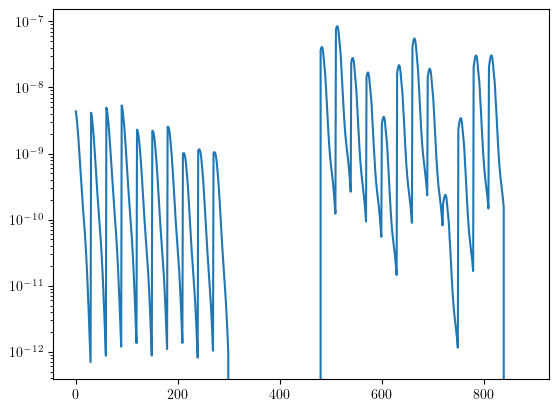

In [33]:
# F_all
# jnp.all(jnp.isfinite(P))
# dmu_cosmo_all.shape
pl.figure()
# pl.plot(np.abs(dmu_cosmo_all[:,0]))
pl.plot(np.abs(dmu_IA_all[:,1]))
# pl.plot(np.abs(dmu_sims_all[:,1]))
pl.yscale('log')




In [47]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as pl
def plot_contours(fisher, pos, inds=[1,0], nstd=1., ax=None,title=None, **kwargs):
  """
  Plot 2D parameter contours given a Hessian matrix of the likelihood
  """
  i,j = inds
  
  def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:, order]

  mat = fisher
  cov = np.linalg.inv(mat)
  sigma_marg = lambda i: np.sqrt(cov[i, i])

  if ax is None:
      ax = pl.gca()

  # Extracts the block we are interested in
  block_cov = cov[:,[i,j]][[i,j],:]
  vals, vecs = eigsorted(block_cov)
  theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

  # Width and height are "full" widths, not radius
  width, height = 2 * nstd * np.sqrt(vals)
  ellip = Ellipse(xy=pos[[i,j]], width=width,
                  height=height, angle=theta, **kwargs)

  ax.add_artist(ellip)
  sz = max(width, height)
  s1 = 1.5*nstd*sigma_marg(i)
  s2 = 1.5*nstd*sigma_marg(j)
  ax.set_xlim(pos[i] - s1, pos[i] + s1)
  ax.set_ylim(pos[j] - s2, pos[j] + s2)
  pl.draw()
  pl.xlabel(r'$\Omega_m$', fontsize=16)
  pl.ylabel(r'$\sigma_8$', fontsize=16)
  pl.xlim(0.295, 0.335)
  pl.ylim(0.81, 0.87)
  if title is not None:
    pl.title(title, fontsize=16)
  return ellip



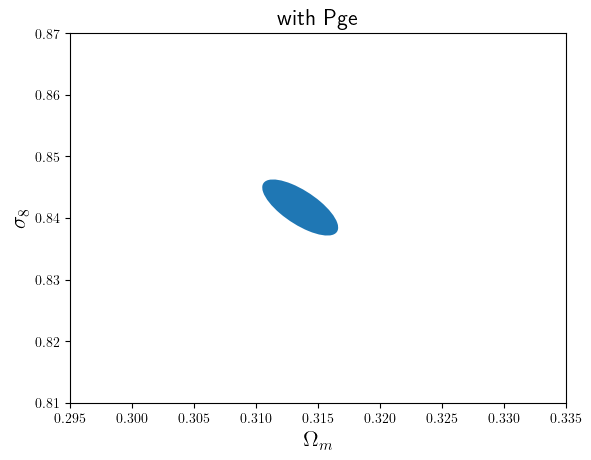

In [39]:
plot_contours(F_all, cosmo_params_fid_all, inds=[0,4], title='with Pge')


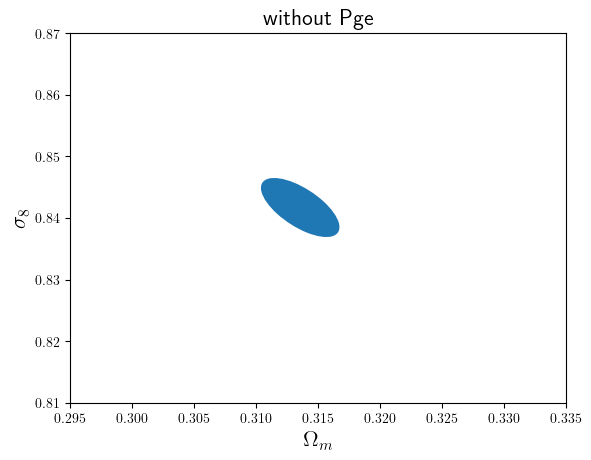

In [48]:
plot_contours(F_all, cosmo_params_fid_all, inds=[0,4], title='without Pge')


ValueError: Axis limits cannot be NaN or Inf

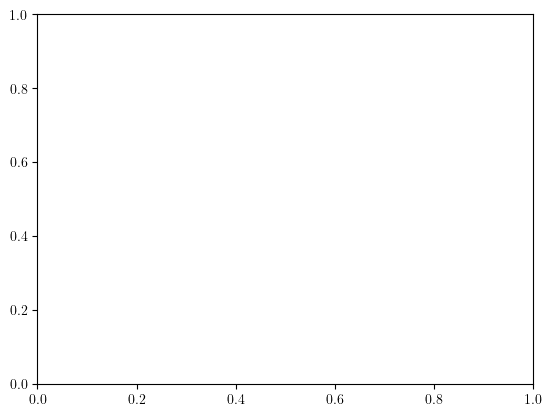

In [37]:
plot_contours(F_all, cosmo_params_fid_all, inds=[0,4])
